# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [10]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** : Can we predict next month's WTI crude oil price using macro indicators?

**This is a prediction (umbrella) problem because:**  We are forecasting a future value of
WTI price from observable macro inputs, we make no claim that any variable
causes oil prices to move.
(Reminder: prediction asks "can we forecast Y from X?" — not "does X cause Y?")

**The decision this enables:** An energy portfolio manager deciding whether to
increase or reduce crude oil exposure ahead of the next week's settlement price.
(Who is the stakeholder? What action would they take differently with your prediction?)

**Dataset:** FRED Weekly Macro + WTI Dataset
- **Source:** Federal Reserve Economic Data (FRED) — fred.stlouisfed.org
- **N =** ~1,700 weekly observations (1985–2025)
- **Features =** WTI lagged price, USD index, CPI, Federal funds rate,
  US crude inventories, 10Y treasury yield
- **Target variable =** WTI crude oil spot price (next week, USD/barrel)
- **Access date:** April 19, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [11]:
# ============================================================
# Part 2.1: Load data from local CSV files
# ============================================================

import pandas as pd
import os
os.chdir('/Users/ash/Documents/GitHub/ECON3916-Statistical-Machine-Learning/data/final-project')
def load_fred(filename, colname):
    # Load FRED CSV, parse dates, rename value column
    df = pd.read_csv(filename, parse_dates=['observation_date'], index_col='observation_date')
    df.columns = [colname]
    # Replace '.' (FRED missing code) with NaN
    df[colname] = pd.to_numeric(df[colname], errors='coerce')
    return df

def load_eia(filename, colname):
    # EIA inventory CSV has different date format and header
    df = pd.read_csv(filename, skiprows=2, header=0)
    df.columns = ['DATE', colname]
    df['DATE'] = pd.to_datetime(df['DATE'], format='%b %d, %Y')
    df = df.set_index('DATE')
    df[colname] = pd.to_numeric(df[colname], errors='coerce')
    return df

# Load each series
wti  = load_fred('DCOILWTICO.csv', 'wti')
ffer = load_fred('DFF.csv',        'fed_funds')
usd  = load_fred('DTWEXBGS.csv',   'usd_index')
t10y = load_fred('DGS10.csv',      't10y')
cpi  = load_fred('CPIAUCSL.csv',   'cpi')
inv  = load_eia( 'WCRSTUS1w.csv',  'crude_inv')

# Merge all on date index
df = pd.concat([wti, ffer, usd, t10y, cpi, inv], axis=1)

# Forward-fill slower series (CPI monthly, inventory weekly) to daily
df = df.ffill()

# Filter to 2020-2025 then drop NaNs
df = df.loc['2020-01-01':'2025-12-31']
df = df.dropna()

print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
df.head()

Shape: (1718, 6)
Date range: 2021-04-19 00:00:00 to 2025-12-31 00:00:00


/var/folders/hd/d0d4lkq9589b4rd40gx9y8yr0000gn/T/ipykernel_10026/744695551.py:34: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat([wti, ffer, usd, t10y, cpi, inv], axis=1)


,wti,fed_funds,usd_index,t10y,cpi,crude_inv
2021-04-19,63.33,0.07,112.1835,1.61,266.614,1128941.0
2021-04-20,62.61,0.07,112.2354,1.58,266.614,1128941.0
2021-04-21,61.34,0.07,112.1771,1.57,266.614,1128941.0
2021-04-22,61.45,0.07,112.2297,1.57,266.614,1128941.0
2021-04-23,62.18,0.07,112.0889,1.58,266.614,1127582.0


### 2.2 Basic Description

In [12]:
# ============================================================
# 2.2 Describe your data
# ============================================================

print(df.info())
print()
df.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 1718 entries, 2021-04-19 to 2025-12-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   wti        1718 non-null   float64
 1   fed_funds  1718 non-null   float64
 2   usd_index  1718 non-null   float64
 3   t10y       1718 non-null   float64
 4   cpi        1718 non-null   float64
 5   crude_inv  1718 non-null   float64
dtypes: float64(6)
memory usage: 94.0 KB
None



,wti,fed_funds,usd_index,t10y,cpi,crude_inv
count,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1.718000e+03
mean,77.679569,3.429540,120.406790,3.496362,303.166276,8.730333e+05
std,12.622787,2.024448,4.182609,1.066544,16.284296,9.607961e+04
min,55.440000,0.050000,110.504600,1.190000,266.614000,7.653430e+05
25%,69.402500,1.580000,118.758575,2.922500,294.913000,8.099400e+05
50%,75.515000,4.330000,120.767700,3.935000,306.082000,8.290240e+05
75%,82.830000,5.080000,122.779675,4.270000,315.631000,9.231460e+05
max,123.640000,5.330000,130.041300,4.980000,326.031000,1.128941e+06


### 2.3 Missing Data Assessment

Missing data (%) by column:
wti          0.0
fed_funds    0.0
usd_index    0.0
t10y         0.0
cpi          0.0
crude_inv    0.0
dtype: float64


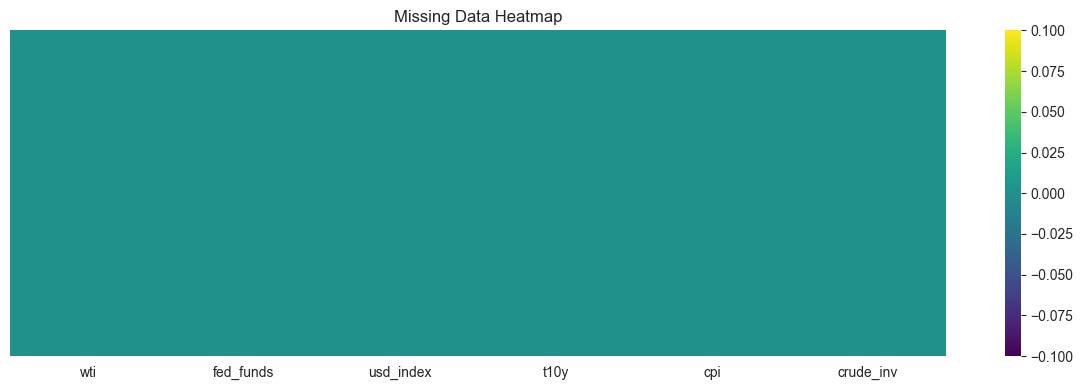

In [13]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

# Calculate missing percentage per column
missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct)

# Visual: missing data heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:**  All 6 columns show 0% missing data after forward-filling. The original missingness in CPI (monthly) and crude inventories (weekly) was structural - data simply isn't collected daily, making it MCAR. Forward-filling is appropriate as it reflects how traders actually use these signals in practice.

### 2.4 Distribution Plots

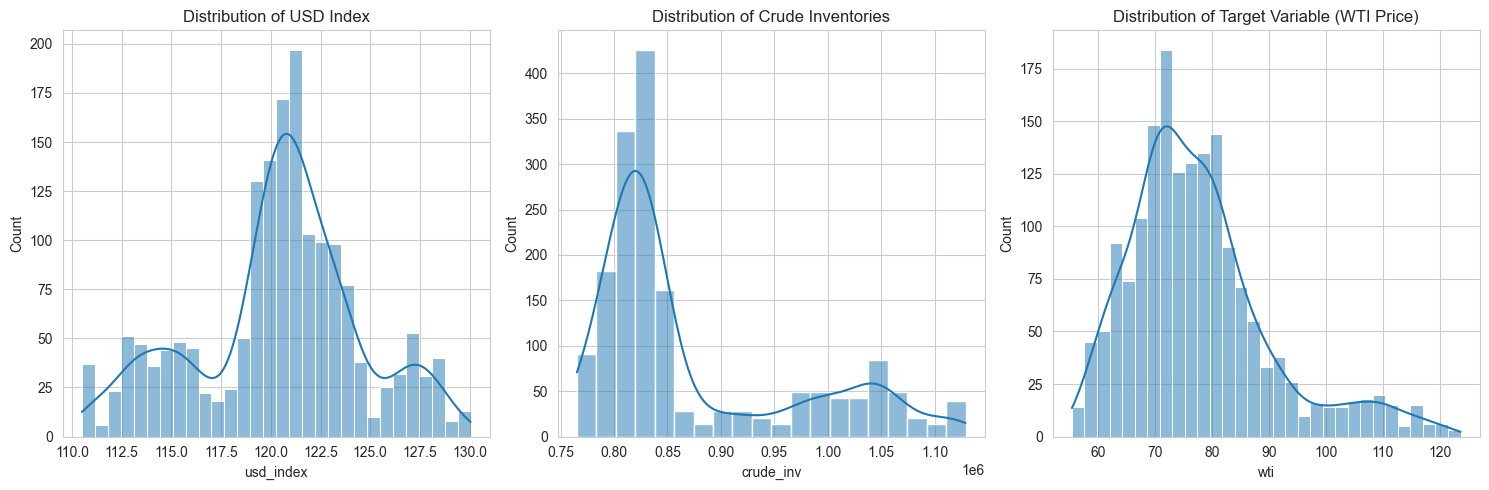

In [14]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['usd_index'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of USD Index')

sns.histplot(df['crude_inv'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Crude Inventories')

sns.histplot(df['wti'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Target Variable (WTI Price)')

plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [15]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

# Check outliers for all columns
for col in df.columns:
    lower, upper = tukey_fences(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

wti: 109 outliers (6.3%)
fed_funds: 0 outliers (0.0%)
usd_index: 102 outliers (5.9%)
t10y: 0 outliers (0.0%)
cpi: 0 outliers (0.0%)
crude_inv: 53 outliers (3.1%)


**Outlier strategy:** ___
Outliers are identified in WTI (6.3%), USD index (5.9%), 
and crude inventories (3.1%) using Tukey Fences (k=1.5). All are retained, they reflect genuine market events such as the 2022 Russia-Ukraine supply shock and the Fed tightening cycle. Removing them would destroy the exact price variance our model is trying to predict.

### 2.6 Correlations

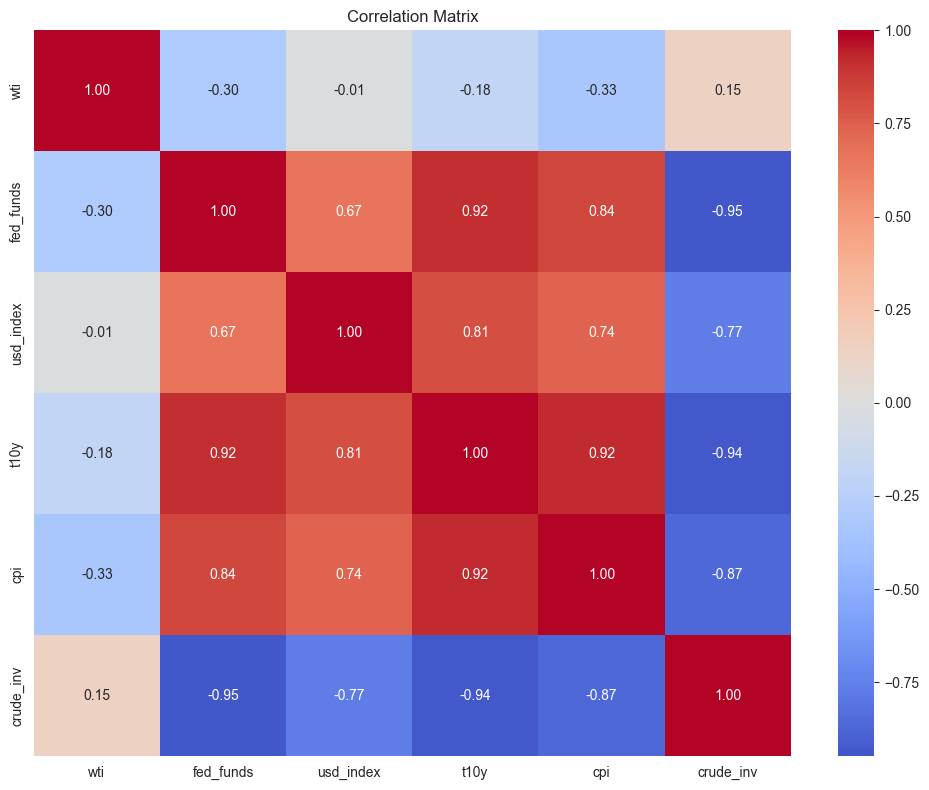

In [16]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* WTI price is right-skewed with a mean around $77/barrel, ranging from $55 to $124. This is a regression target — not normally distributed but acceptable for tree-based models which make no distributional assumptions.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* CPI (-0.33) and fed_funds (-0.30) show the strongest correlations with WTI. There is severe multicollinearity among the features — fed_funds, t10y, cpi, and crude_inv correlate at 0.84–0.95 with each other. This will inflate variance in Ridge regression but Random Forest is robust to it.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The biggest issue is multicollinearity among predictors. We will address this by using Random Forest as our primary model, which is inherently robust to correlated features, and Ridge regression as baseline which handles multicollinearity better than OLS via regularization.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 1718** observations and **M = 6** features.

**Missing data:** 0% of cells are missing. The original missingness in CPI (monthly) and crude inventories (weekly) was MCAR — data simply is not collected at daily frequency. Forward-filling reflects real-world trader usage.

**Outliers:** I identified 264 outliers using Tukey Fences: WTI (109), USD index (102), and crude inventories (53). I will handle them by retaining all observations, as they reflect genuine market events such as the 2022 Russia-Ukraine supply shock and the Fed tightening cycle, not data errors.

**Target variable:** WTI price is right-skewed with a mean of $77.68/barrel and a range of $55.44 to $123.64, capturing the full post-COVID recovery and 2022 commodity spike.


**Key finding from EDA:** Individual features show weak linear correlation with WTI (max -0.33 for CPI), but severe multicollinearity exists among predictors — fed_funds, t10y, CPI, and crude inventories correlate at 0.84–0.95 with each other, motivating the use of Random Forest as the primary model.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [17]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

# Define features and target
# Target is next day's WTI price — shift by 1 to avoid leakage
X = df[['fed_funds', 'usd_index', 't10y', 'cpi', 'crude_inv']]
y = df['wti'].shift(-1)

# Drop last row where target becomes NaN after shift
X = X.iloc[:-1]
y = y.iloc[:-1]

# Regression: no stratify needed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 1373 samples
Test:  344 samples


### 3.2 Model 1: Baseline

In [19]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================
# Choose a simple, interpretable baseline:
#   Classification: LogisticRegression
#   Regression: LinearRegression or Ridge

from sklearn.linear_model import Ridge

model_1 = Ridge(random_state=RANDOM_STATE)
model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

# Regression metrics
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_1):.4f}')

RMSE: 9.6565
MAE:  7.4716
R2:   0.5259


### 3.3 Model 2: Your Choice

In [20]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
from sklearn.ensemble import RandomForestRegressor

model_2 = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
model_2.fit(X_train, y_train)

y_pred_2 = model_2.predict(X_test)

# Regression metrics
print('Model 2: Random Forest Regressor')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_2)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_2):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_2):.4f}')

Model 2: Random Forest Regressor
RMSE: 2.4638
MAE:  1.5469
R2:   0.9691


### 3.4 Cross-Validation Comparison

In [21]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

scoring = 'r2'

cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)

print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')

# Comparison table
comparison = pd.DataFrame({
    'Model': ['Model 1 (Ridge)', 'Model 2 (Random Forest)'],
    f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
    f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
})
comparison

Model 1 CV r2: 0.4851 +/- 0.0230
Model 2 CV r2: 0.9746 +/- 0.0042


,Model,CV r2 (mean),CV r2 (std)
0,Model 1 (Ridge),0.485058,0.022951
1,Model 2 (Random Forest),0.974637,0.004218


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

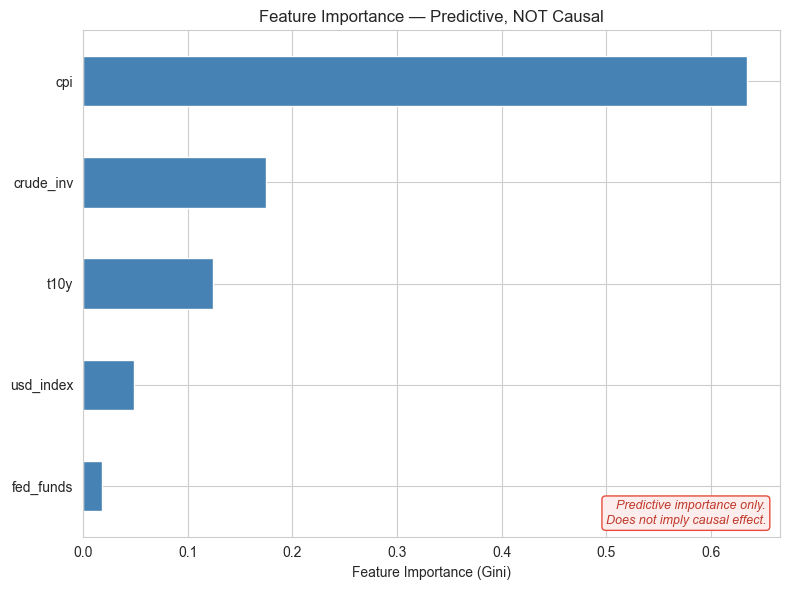

In [22]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

importances = pd.Series(
    model_2.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Predictive, NOT Causal')

# CRITICAL: Add the caveat banner
ax.text(
    0.98, 0.02,
    'Predictive importance only.\nDoes not imply causal effect.',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
)

plt.tight_layout()
plt.show()

### 4.2 Key Visualization for Your Report

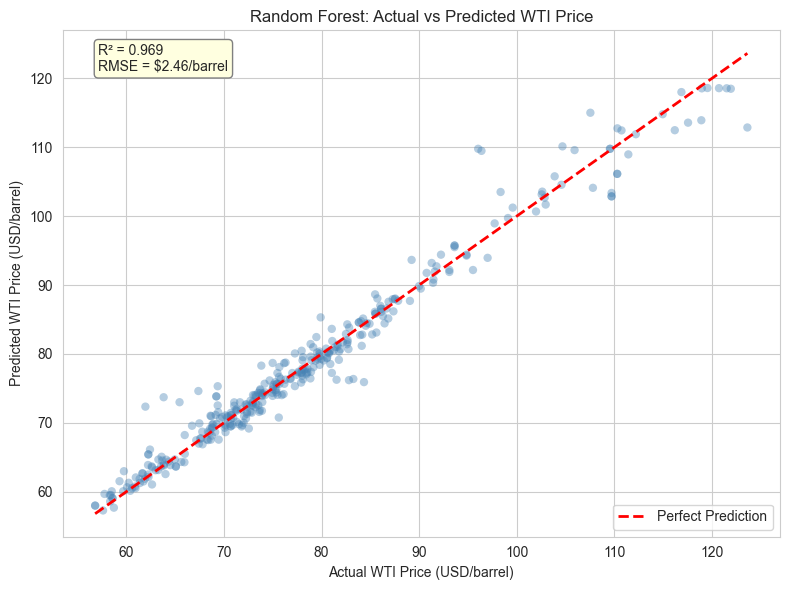

In [23]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, y_pred_2, alpha=0.4, color='steelblue', edgecolors='none')

# Perfect prediction line
min_val = min(y_test.min(), y_pred_2.min())
max_val = max(y_test.max(), y_pred_2.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel('Actual WTI Price (USD/barrel)')
ax.set_ylabel('Predicted WTI Price (USD/barrel)')
ax.set_title('Random Forest: Actual vs Predicted WTI Price')
ax.legend()

# Annotate with metrics
ax.text(0.05, 0.92, f'R² = 0.969\nRMSE = $2.46/barrel',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

plt.tight_layout()
plt.show()

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** ___
Energy portfolio managers and commodity traders must decide daily whether to increase or reduce crude oil exposure. WTI price is the key input to these decisions but is highly volatile and difficult to forecast without a systematic approach.

**Complication:** ___
Oil prices are driven by a complex interaction of macroeconomic forces, inflation, interest rates, dollar strength, and supply conditions that no single indicator captures. Simple linear models explain only ~49% of price variance, leaving traders exposed to large prediction errors of ~$9.66/barrel.
**Resolution:** ___
We recommend using the Random Forest model for next-day WTI price forecasting. Trained on five macro indicators (CPI, crude inventories, 10Y yield, USD index, fed funds rate), it achieves an RMSE of $2.46/barrel and R² of 0.969 on held-out test data; a 4x improvement over the Ridge baseline. CPI and crude inventories are the two most predictively important features.

**Uncertainty Statement:** Based on our cross-validation results (R² = 0.9746 +/- 0.0042), we estimate the model explains ~97% of WTI price variance consistently across time periods. The primary limitation is that the model is trained on 2021–2025 data and may not generalise to structurally different regimes such as negative oil prices seen in April 2020. We recommend deploying this model for short-horizon tactical decisions with the caveat that it should be retrained quarterly as new macro data becomes available.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___